In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
from datetime import datetime, timedelta
from pyspark.sql.functions import sum, count, date_format, col
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import (
    RegressionEvaluator,
    BinaryClassificationEvaluator,
    ClusteringEvaluator
)

warnings.filterwarnings("ignore")


In [ ]:
# Load Customers
customers_df = spark.read.option("header", True) \
    .option("inferSchema", True) \
    .csv("dbfs:/FileStore/tables/customers_data.csv")

# Load Products
products_df = spark.read.option("header", True) \
    .option("inferSchema", True) \
    .csv("dbfs:/FileStore/tables/products_data.csv")

# Load Transactions
transactions_df = spark.read.option("header", True) \
    .option("inferSchema", True) \
    .csv("dbfs:/FileStore/tables/transactions_data.csv")


In [ ]:
full_df = transactions_df \
    .join(customers_df, "customer_id") \
    .join(products_df, "product_id")


In [ ]:
customers_df = spark.read.format("com.crealytics.spark.excel") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("file:/Workspace/Users/lakshmipurammanish@gmail.com/DS 610_Project_Execution/customers_data.xlsx")


In [ ]:
products_df = spark.read.format("com.crealytics.spark.excel") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("file:/Workspace/Users/lakshmipurammanish@gmail.com/DS 610_Project_Execution/products_data.xlsx")


In [ ]:
transactions_df = spark.read.format("com.crealytics.spark.excel") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("file:/Workspace/Users/lakshmipurammanish@gmail.com/DS 610_Project_Execution/transactions_data.xlsx")


In [ ]:
full_df = transactions_df \
    .join(customers_df, "customer_id") \
    .join(products_df, "product_id")


In [ ]:
customers_df = spark.table("workspace.default.customers")
products_df = spark.table("workspace.default.products")
transactions_df = spark.table("workspace.default.transactions")


In [ ]:
full_df = transactions_df \
    .join(customers_df, "customer_id") \
    .join(products_df, "product_id")

print("Full dataset count:", full_df.count())


Full dataset count: 50000


In [ ]:
from pyspark.sql.functions import sum

full_df.groupBy("region") \
    .agg(sum("total_amount").alias("total_revenue")) \
    .orderBy("total_revenue", ascending=False) \
    .show()


+-------+-------------+
| region|total_revenue|
+-------+-------------+
|   East|  10640695.92|
|Central|  10590674.54|
|  South|  10496681.44|
|  North|  10460856.58|
|   West|  10165644.82|
+-------+-------------+



In [ ]:

monthly_revenue = transactions_df \
    .withColumn("month", date_format("transaction_date", "yyyy-MM")) \
    .groupBy("month") \
    .agg(
        sum("total_amount").alias("total_revenue"),
        count("transaction_id").alias("total_transactions")
    ) \
    .orderBy("month")

monthly_revenue.show(20)


+-------+-------------+------------------+
|  month|total_revenue|total_transactions|
+-------+-------------+------------------+
|2023-01|   2250354.70|              2121|
|2023-02|   2156995.90|              1897|
|2023-03|   2261360.22|              2185|
|2023-04|   2157398.71|              2119|
|2023-05|   2199688.42|              2111|
|2023-06|   2126789.26|              2024|
|2023-07|   2163948.78|              2115|
|2023-08|   2264597.09|              2071|
|2023-09|   2070074.01|              1997|
|2023-10|   2303521.98|              2124|
|2023-11|   2211626.53|              2015|
|2023-12|   2232213.44|              2126|
|2024-01|   2307334.58|              2176|
|2024-02|   2064157.95|              1982|
|2024-03|   2056519.54|              2125|
|2024-04|   2176321.31|              2061|
|2024-05|   2235058.05|              2132|
|2024-06|   2045247.48|              2062|
|2024-07|   2122587.49|              2085|
|2024-08|   2241070.45|              2069|
+-------+--

In [ ]:
top_customers = full_df \
    .groupBy("customer_id", "first_name", "last_name") \
    .agg(sum("total_amount").alias("lifetime_value")) \
    .orderBy("lifetime_value", ascending=False) \
    .limit(10)

top_customers.show()


+-----------+----------+---------+--------------+
|customer_id|first_name|last_name|lifetime_value|
+-----------+----------+---------+--------------+
|       2234|      John|    Lewis|      37399.42|
|        469| Stephanie|   Wilson|      36394.33|
|       4519|    Joseph|   Wilson|      35004.27|
|       4182|     Susan|   Thomas|      34799.08|
|       1029|     Jason|    Perez|      34415.48|
|       3020|   Timothy|   Rivera|      33910.40|
|       1691|   Michael|    Green|      33625.62|
|       2416|    Daniel|   Taylor|      33527.61|
|        873|     Betty|  Jackson|      33341.38|
|       4528|     Linda|   Walker|      32941.44|
+-----------+----------+---------+--------------+



In [ ]:
category_revenue = full_df \
    .groupBy("category") \
    .agg(sum("total_amount").alias("category_revenue")) \
    .orderBy("category_revenue", ascending=False)

category_revenue.show()


+-------------+----------------+
|     category|category_revenue|
+-------------+----------------+
|  Electronics|     17221809.50|
|    Furniture|     12691571.05|
|       Sports|      5470461.06|
| Toys & Games|      4429852.76|
|Home & Garden|      3532896.77|
|       Beauty|      3334373.85|
|        Books|      3216440.44|
|     Clothing|      2457147.87|
+-------------+----------------+



In [ ]:
segment_performance = full_df \
    .groupBy("customer_segment") \
    .agg(
        sum("total_amount").alias("segment_revenue"),
        count("transaction_id").alias("transactions")
    ) \
    .orderBy("segment_revenue", ascending=False)

segment_performance.show()


+----------------+---------------+------------+
|customer_segment|segment_revenue|transactions|
+----------------+---------------+------------+
|        Standard|    22241032.40|       23447|
|           Basic|    13324476.47|       14136|
|         Premium|    10502582.40|        7630|
|             VIP|     6286462.03|        4787|
+----------------+---------------+------------+



In [ ]:
full_df.createOrReplaceTempView("ecommerce_full")


In [ ]:
# Aggregate customer metrics
customer_features = full_df.groupBy("customer_id") \
    .agg(
        sum("total_amount").alias("total_spent"),
        count("transaction_id").alias("total_orders")
    )

# Assemble features
assembler = VectorAssembler(
    inputCols=["total_spent", "total_orders"],
    outputCol="features"
)

kmeans = KMeans(k=4, seed=42)

pipeline = Pipeline(stages=[assembler, kmeans])

model = pipeline.fit(customer_features)

clustered_customers = model.transform(customer_features)

clustered_customers.select("customer_id", "prediction").show(10)


+-----------+----------+
|customer_id|prediction|
+-----------+----------+
|       2858|         0|
|       1534|         0|
|       3681|         2|
|       2304|         1|
|        952|         0|
|       4600|         2|
|       1829|         2|
|        569|         1|
|        517|         3|
|       1769|         0|
+-----------+----------+
only showing top 10 rows


In [ ]:
# Index categorical column
indexer = StringIndexer(
    inputCol="payment_method",
    outputCol="payment_method_index"
)

# Feature assembler
assembler = VectorAssembler(
    inputCols=["quantity", "unit_price", "discount_percent", "tax_amount", "payment_method_index"],
    outputCol="features"
)

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_amount"
)

pipeline = Pipeline(stages=[indexer, assembler, rf])

train_data, test_data = transactions_df.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train_data)

predictions = model.transform(test_data)

predictions.select("total_amount", "prediction").show(10)


+------------+------------------+
|total_amount|        prediction|
+------------+------------------+
|      883.75| 913.1744726312814|
|      389.08|368.20295817284637|
|      447.53| 534.3641720294061|
|     1225.20| 1200.140028128878|
|      174.79|191.85418204379783|
|     2096.71|1740.5342234503175|
|      762.60| 728.4266637620512|
|     2490.60| 2470.163178133761|
|     1438.16|1579.1420187468116|
|     1716.19|1583.0518982070275|
+------------+------------------+
only showing top 10 rows


In [ ]:
# Convert boolean to integer
transactions_ml = transactions_df.withColumn(
    "label",
    transactions_df.is_returned.cast("int")
)

assembler = VectorAssembler(
    inputCols=["quantity", "unit_price", "discount_percent", "tax_amount"],
    outputCol="features"
)

lr = LogisticRegression(featuresCol="features", labelCol="label")

pipeline = Pipeline(stages=[assembler, lr])

train_data, test_data = transactions_ml.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train_data)

predictions = model.transform(test_data)

predictions.select("label", "prediction", "probability").show(10)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.94814858353501...|
|    0|       0.0|[0.94713667345207...|
|    0|       0.0|[0.94735959319485...|
|    0|       0.0|[0.95135436187651...|
|    0|       0.0|[0.94389306455350...|
|    1|       0.0|[0.95323049862573...|
|    0|       0.0|[0.94753575264500...|
|    0|       0.0|[0.95137167072153...|
|    0|       0.0|[0.94795304918707...|
|    0|       0.0|[0.95096464788762...|
+-----+----------+--------------------+
only showing top 10 rows


In [ ]:
# Load tables
customers_df = spark.table("workspace.default.customers")
products_df = spark.table("workspace.default.products")
transactions_df = spark.table("workspace.default.transactions")

# Join tables
full_df = transactions_df \
    .join(customers_df, "customer_id") \
    .join(products_df, "product_id")

# Aggregate customer features
customer_features = full_df.groupBy("customer_id") \
    .agg(
        sum("total_amount").alias("total_spent"),
        count("transaction_id").alias("total_orders")
    )

# ML Pipeline
assembler = VectorAssembler(
    inputCols=["total_spent", "total_orders"],
    outputCol="features"
)

kmeans = KMeans(k=4, seed=42)

pipeline = Pipeline(stages=[assembler, kmeans])

model = pipeline.fit(customer_features)

clustered_customers = model.transform(customer_features)

# Save as managed table
clustered_customers.write.mode("overwrite") \
    .saveAsTable("workspace.default.customer_clusters")

print("Customer clustering completed and saved successfully!")


Customer clustering completed and saved successfully!


In [ ]:
%sql
SELECT prediction AS cluster,
       COUNT(*) AS customers,
       AVG(total_spent) AS avg_spending
FROM workspace.default.customer_clusters
GROUP BY prediction
ORDER BY avg_spending DESC;


cluster,customers,avg_spending
2,356,23058.344326
1,1121,15052.487654
0,1946,9815.697492
3,1577,5181.101294


In [ ]:


evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction",
    metricName="silhouette"
)

silhouette_score = evaluator.evaluate(clustered_customers)

print("Silhouette Score:", silhouette_score)



Silhouette Score: 0.6919587050704913


In [ ]:

# Prepare ML dataset
ml_df = transactions_df.select(
    "quantity",
    "unit_price",
    "discount_percent",
    "tax_amount",
    "payment_method",
    "total_amount"
)

# Encode categorical variable
indexer = StringIndexer(
    inputCol="payment_method",
    outputCol="payment_method_index"
)

assembler = VectorAssembler(
    inputCols=[
        "quantity",
        "unit_price",
        "discount_percent",
        "tax_amount",
        "payment_method_index"
    ],
    outputCol="features"
)

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_amount",
    numTrees=50
)

pipeline = Pipeline(stages=[indexer, assembler, rf])

train, test = ml_df.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train)

predictions = model.transform(test)

predictions.select("total_amount", "prediction").show(10)


+------------+------------------+
|total_amount|        prediction|
+------------+------------------+
|       22.88|160.52453891128033|
|       31.77|153.54973169426808|
|       10.66| 151.5976940536699|
|       11.56|153.61362172317237|
|       32.83|161.95710964620238|
|       11.56|160.52453891128033|
|       25.96|160.52453891128033|
|       32.50|153.54973169426808|
|       32.34|153.61362172317237|
|       20.44|160.52453891128033|
+------------+------------------+
only showing top 10 rows


In [ ]:
rf_model = model.stages[-1]


feature_importance = rf_model.featureImportances

feature_names = [
    "quantity",
    "unit_price",
    "discount_percent",
    "tax_amount",
    "payment_method_index"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance.toArray()
})

importance_df.sort_values(by="Importance", ascending=False)


,Feature,Importance
3,tax_amount,0.585615
1,unit_price,0.329101
0,quantity,0.083674
2,discount_percent,0.001407
4,payment_method_index,0.000204


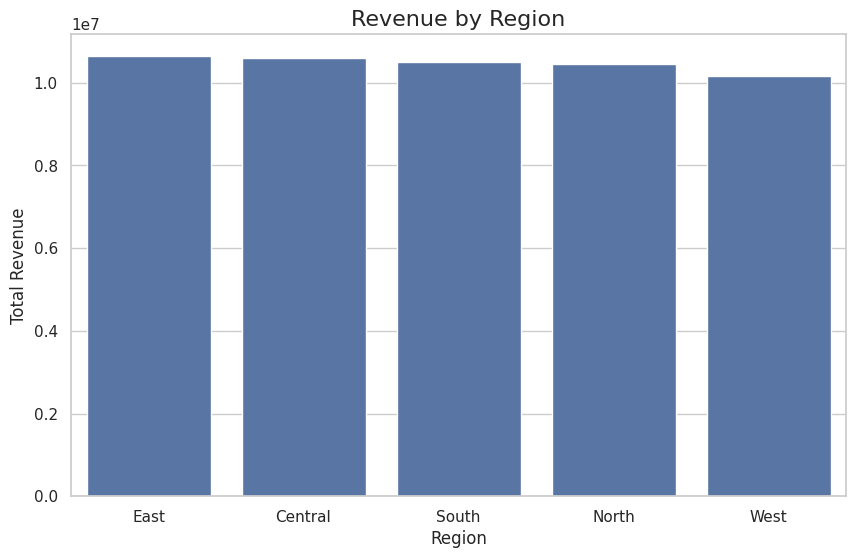

In [ ]:

full_df = spark.table("workspace.default.transactions") \
    .join(spark.table("workspace.default.customers"), "customer_id") \
    .join(spark.table("workspace.default.products"), "product_id")

region_pd = full_df.groupBy("region") \
    .agg(sum("total_amount").alias("total_revenue")) \
    .orderBy("total_revenue", ascending=False) \
    .toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=region_pd, x="region", y="total_revenue")
plt.title("Revenue by Region", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.show()


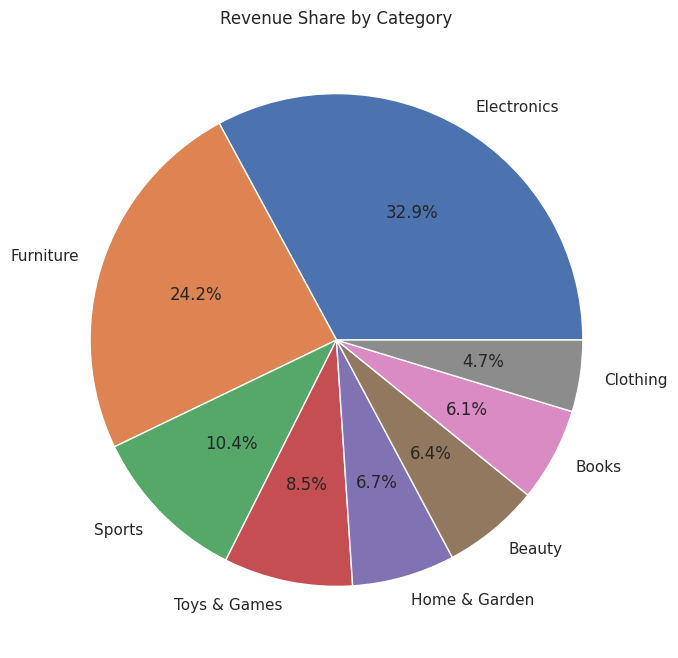

In [ ]:
full_df = spark.table("workspace.default.transactions") \
    .join(spark.table("workspace.default.products"), "product_id")

category_pd = full_df.groupBy("category") \
    .agg(sum("total_amount").alias("revenue")) \
    .orderBy("revenue", ascending=False) \
    .toPandas()

plt.figure(figsize=(8,8))
plt.pie(category_pd["revenue"],
        labels=category_pd["category"],
        autopct='%1.1f%%')
plt.title("Revenue Share by Category")
plt.show()


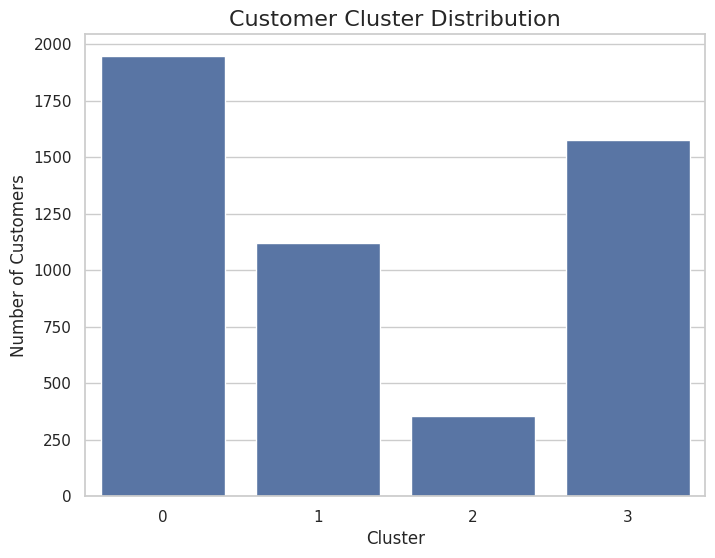

In [ ]:
cluster_pd = spark.table("workspace.default.customer_clusters") \
    .groupBy("prediction") \
    .count() \
    .toPandas()

plt.figure(figsize=(8,6))
sns.barplot(data=cluster_pd, x="prediction", y="count")
plt.title("Customer Cluster Distribution", fontsize=16)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


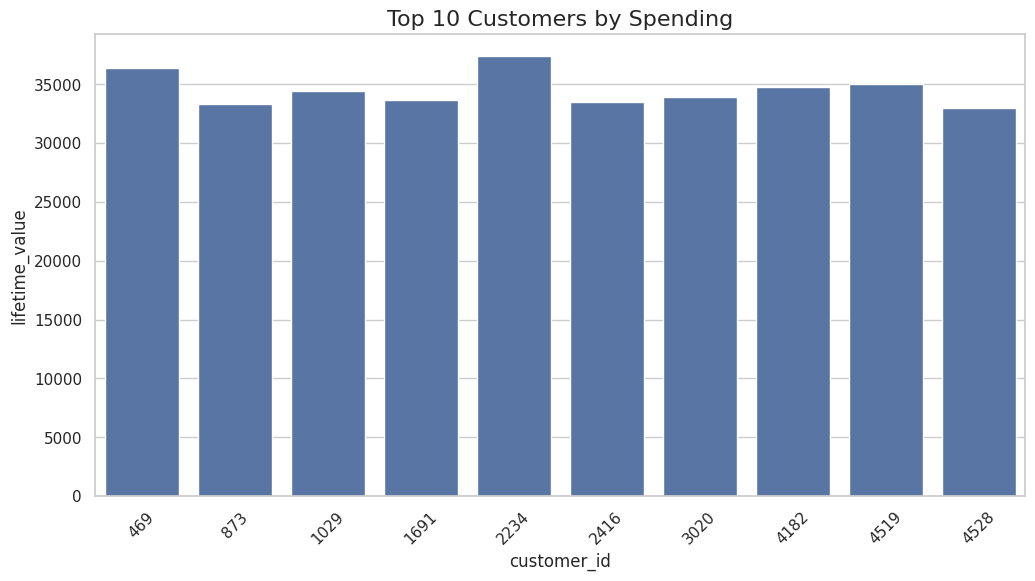

In [ ]:
full_df = spark.table("workspace.default.transactions") \
    .join(spark.table("workspace.default.customers"), "customer_id")

top_customers_pd = full_df.groupBy("customer_id") \
    .agg(sum("total_amount").alias("lifetime_value")) \
    .orderBy("lifetime_value", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=top_customers_pd,
            x="customer_id",
            y="lifetime_value")
plt.title("Top 10 Customers by Spending", fontsize=16)
plt.xticks(rotation=45)
plt.show()


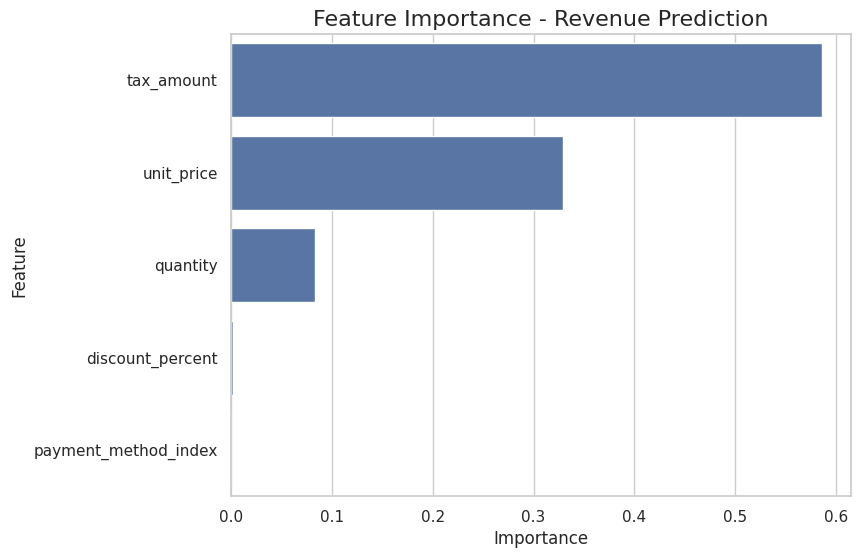

In [ ]:

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df.sort_values(by="Importance", ascending=False),
            x="Importance", y="Feature")
plt.title("Feature Importance - Revenue Prediction", fontsize=16)
plt.show()


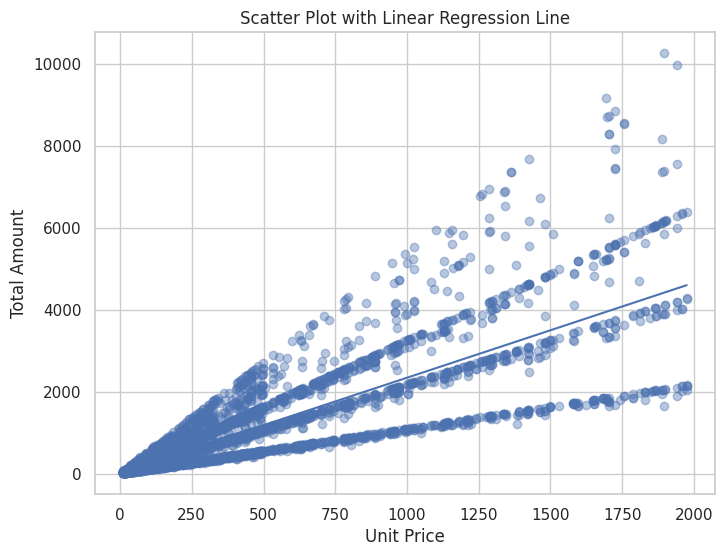

In [ ]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import numpy as np

# Load and convert to float to avoid Decimal error
data_pd = spark.table("workspace.default.transactions") \
    .select("unit_price", "total_amount") \
    .filter(col("unit_price").isNotNull()) \
    .filter(col("total_amount").isNotNull()) \
    .limit(5000) \
    .toPandas()

# Convert Decimal to float
data_pd["unit_price"] = data_pd["unit_price"].astype(float)
data_pd["total_amount"] = data_pd["total_amount"].astype(float)

x = data_pd["unit_price"].values
y = data_pd["total_amount"].values

# Fit regression line
m, b = np.polyfit(x, y, 1)

# Create sorted x values for straight line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

# Plot
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.4)
plt.plot(x_line, y_line)   # Clean straight regression line
plt.title("Scatter Plot with Linear Regression Line")
plt.xlabel("Unit Price")
plt.ylabel("Total Amount")
plt.show()


In [ ]:
from pyspark.sql.functions import date_format, sum
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline

# 1️⃣ Read from Catalog table (SAFE)
transactions_df = spark.table("workspace.default.transactions")

# 2️⃣ Create monthly revenue dataset
monthly_sales = transactions_df \
    .withColumn("month", date_format("transaction_date", "yyyyMM").cast("int")) \
    .groupBy("month") \
    .agg(sum("total_amount").alias("revenue")) \
    .orderBy("month")

# 3️⃣ Feature engineering
assembler = VectorAssembler(inputCols=["month"], outputCol="features")

# 4️⃣ Train model
rf = RandomForestRegressor(featuresCol="features", labelCol="revenue")
pipeline = Pipeline(stages=[assembler, rf])
model = pipeline.fit(monthly_sales)

# 5️⃣ Predict future months
future_months = spark.createDataFrame([
    (202501,), (202502,), (202503,), (202504,)
], ["month"])

future_predictions = model.transform(future_months)

future_predictions.select("month", "prediction").show()

+------+-----------------+
| month|       prediction|
+------+-----------------+
|202501|2203617.378166666|
|202502|2203617.378166666|
|202503|2203617.378166666|
|202504|2203617.378166666|
+------+-----------------+



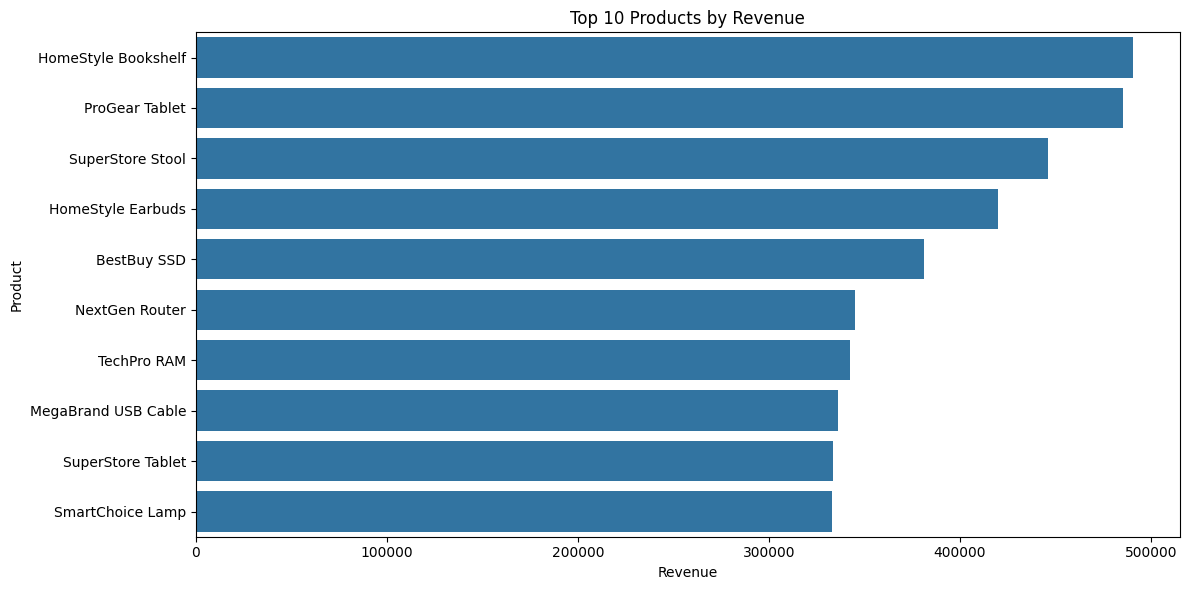

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import sum, col

#Ensure full_df exists
customers_df = spark.table("workspace.default.customers")
products_df = spark.table("workspace.default.products")
transactions_df = spark.table("workspace.default.transactions")

full_df = transactions_df \
    .join(customers_df, "customer_id") \
    .join(products_df, "product_id")

#Aggregate revenue by product
top_products = full_df.groupBy("product_name") \
    .agg(sum("total_amount").alias("revenue")) \
    .orderBy(col("revenue").desc()) \
    .limit(10)

# Convert to Pandas
top_products_pd = top_products.toPandas()
top_products_pd["revenue"] = top_products_pd["revenue"].astype(float)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_products_pd,
    x="revenue",
    y="product_name"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import col

profit_df = full_df \
    .withColumn("profit", col("total_amount") - (col("cost") * col("quantity")))

profit_df.groupBy("category") \
    .agg(sum("profit").alias("total_profit")) \
    .orderBy(col("total_profit").desc()) \
    .show()

+-------------+------------+
|     category|total_profit|
+-------------+------------+
|  Electronics|  8479023.28|
|    Furniture|  6046664.15|
|       Sports|  2618584.71|
| Toys & Games|  2157212.48|
|Home & Garden|  1711075.53|
|       Beauty|  1594088.97|
|        Books|  1528999.56|
|     Clothing|  1238271.41|
+-------------+------------+



In [ ]:
from pyspark.sql.functions import max, count, sum, datediff, current_date, col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Load transactions
transactions_df = spark.table("workspace.default.transactions")

# Create CLV dataset
clv_df = transactions_df.groupBy("customer_id") \
    .agg(
        max("transaction_date").alias("last_purchase"),
        count("transaction_id").alias("total_orders"),
        sum("total_amount").alias("lifetime_value")
    ) \
    .withColumn("recency", datediff(current_date(), "last_purchase"))

# Feature engineering
assembler = VectorAssembler(
    inputCols=["recency", "total_orders"],
    outputCol="features"
)

# Train regression model
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="lifetime_value",
    numTrees=50
)

pipeline = Pipeline(stages=[assembler, rf])

train, test = clv_df.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train)

# Predictions
predictions = model.transform(test)

# Evaluate
evaluator = RegressionEvaluator(
    labelCol="lifetime_value",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)

print("CLV Model RMSE:", rmse)
auc = evaluator.evaluate(predictions)

print("Churn Model AUC:", auc)

# Show predictions
predictions.select("customer_id", "lifetime_value", "prediction").show(10)

CLV Model RMSE: 4364.396751759015
Churn Model AUC: 4364.396751759015
+-----------+--------------+------------------+
|customer_id|lifetime_value|        prediction|
+-----------+--------------+------------------+
|          9|       5102.34| 8946.018444207366|
|         12|       7528.66| 5692.809333746304|
|         14|       6421.56|10601.427023810917|
|         22|       8177.15| 9116.390355944573|
|         24|       4847.28|  6420.49730686581|
|         25|      15462.19| 6704.973154067894|
|         26|       8749.78| 8978.990084457055|
|         28|       6994.20|10331.722790186432|
|         31|      10622.10| 6509.431838587874|
|         35|      19323.09| 11386.10345916022|
+-----------+--------------+------------------+
only showing top 10 rows


+-----------+--------------+----------------+
|customer_id|lifetime_value|customer_segment|
+-----------+--------------+----------------+
|       2234|      37399.42|             VIP|
|        469|      36394.33|             VIP|
|       4519|      35004.27|             VIP|
|       4182|      34799.08|             VIP|
|       1029|      34415.48|             VIP|
|       3020|      33910.40|             VIP|
|       1691|      33625.62|             VIP|
|       2416|      33527.61|             VIP|
|        873|      33341.38|             VIP|
|       4528|      32941.44|             VIP|
+-----------+--------------+----------------+
only showing top 10 rows


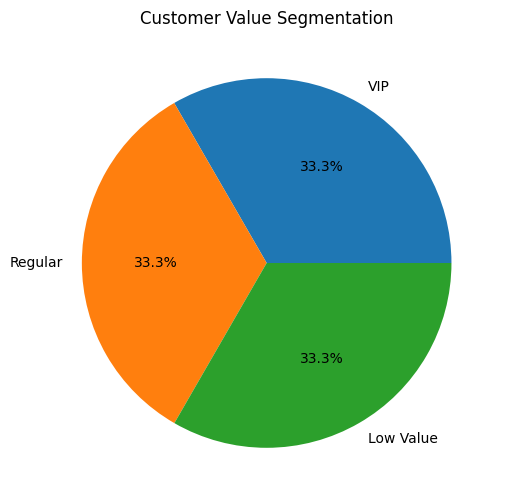

In [ ]:
from pyspark.sql.functions import sum, col, ntile, when
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# Load transactions
transactions_df = spark.table("workspace.default.transactions")

# Create CLV dataset
clv_df = transactions_df.groupBy("customer_id") \
    .agg(sum("total_amount").alias("lifetime_value"))

# Segment customers into tiers
window_spec = Window.orderBy(col("lifetime_value").desc())

clv_segmented = clv_df \
    .withColumn("tier", ntile(3).over(window_spec)) \
    .withColumn(
        "customer_segment",
        when(col("tier") == 1, "VIP")
        .when(col("tier") == 2, "Regular")
        .otherwise("Low Value")
    )

# Show table
clv_segmented.select("customer_id", "lifetime_value", "customer_segment").show(10)

# Aggregate for visualization
seg_count = clv_segmented.groupBy("customer_segment").count()
seg_pd = seg_count.toPandas()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(seg_pd["count"], labels=seg_pd["customer_segment"], autopct='%1.1f%%')
plt.title("Customer Value Segmentation")
plt.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------+---------+--------+-----------+
|customer_id|recency|frequency|monetary|    segment|
+-----------+-------+---------+--------+-----------+
|       2345|   1086|        1| 2354.24|Hibernating|
|       3230|    885|        1|  715.59|Hibernating|
|       4268|    650|        1|  382.94|Hibernating|
|        170|    473|        1|  558.53|Hibernating|
|       1174|    449|        1|  801.71|    At Risk|
|       3650|    423|        1|   56.01|    At Risk|
|       4862|   1018|        2|  679.23|Hibernating|
|       3603|    954|        2| 1790.24|Hibernating|
|        419|    906|        2| 2451.58|Hibernating|
|       3281|    839|        2| 2631.07|Hibernating|
+-----------+-------+---------+--------+-----------+
only showing top 10 rows


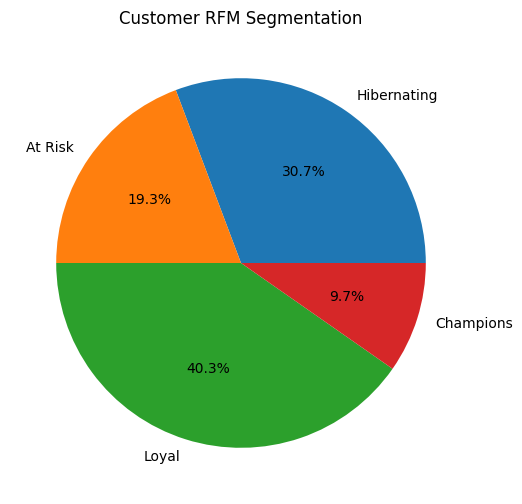

In [ ]:
from pyspark.sql.functions import max, count, sum, datediff, current_date, col, ntile, when
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# Load transactions
transactions_df = spark.table("workspace.default.transactions")

#Calculate RFM metrics
rfm = transactions_df.groupBy("customer_id") \
    .agg(
        max("transaction_date").alias("last_purchase"),
        count("transaction_id").alias("frequency"),
        sum("total_amount").alias("monetary")
    ) \
    .withColumn("recency", datediff(current_date(), "last_purchase"))

# Rank RFM scores
recency_window = Window.orderBy(col("recency").desc())
freq_window = Window.orderBy(col("frequency"))
mon_window = Window.orderBy(col("monetary"))

rfm = rfm \
    .withColumn("R", ntile(4).over(recency_window)) \
    .withColumn("F", ntile(4).over(freq_window)) \
    .withColumn("M", ntile(4).over(mon_window))

# Create RFM segments
rfm = rfm.withColumn(
    "segment",
    when((col("R") == 4) & (col("F") == 4), "Champions")
    .when((col("F") >= 3), "Loyal")
    .when((col("R") >= 3), "At Risk")
    .otherwise("Hibernating")
)

# Show RFM table
rfm.select("customer_id", "recency", "frequency", "monetary", "segment").show(10)

# Visualization
rfm_pd = rfm.groupBy("segment").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(rfm_pd["count"], labels=rfm_pd["segment"], autopct='%1.1f%%')
plt.title("Customer RFM Segmentation")
plt.show()

========== EXECUTIVE KPI DASHBOARD ==========
Total Revenue: $52,354,553.30
Total Orders: 50,000
Total Customers: 5,000
Avg Order Value: $1,047.09
Top Performing Region: East


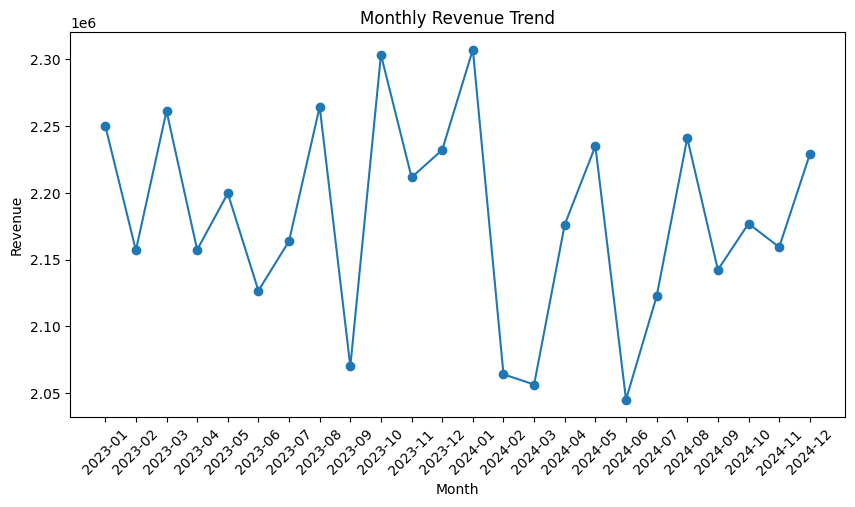

In [ ]:
from pyspark.sql.functions import sum, countDistinct, count, avg, col, date_format
import matplotlib.pyplot as plt

# ⭐ Load data from catalog
transactions_df = spark.table("workspace.default.transactions")
customers_df = spark.table("workspace.default.customers")

# ⭐ Compute KPIs
total_revenue = transactions_df.agg(sum("total_amount")).collect()[0][0]
total_orders = transactions_df.agg(count("transaction_id")).collect()[0][0]
total_customers = customers_df.agg(countDistinct("customer_id")).collect()[0][0]
avg_order_value = transactions_df.agg(avg("total_amount")).collect()[0][0]

# Top region
top_region = transactions_df.groupBy("region") \
    .agg(sum("total_amount").alias("rev")) \
    .orderBy(col("rev").desc()) \
    .first()["region"]

# Monthly revenue trend
monthly = transactions_df \
    .withColumn("month", date_format("transaction_date", "yyyy-MM")) \
    .groupBy("month").agg(sum("total_amount").alias("revenue")) \
    .orderBy("month")

monthly_pd = monthly.toPandas()

#  KPI PRINT
print("========== EXECUTIVE KPI DASHBOARD ==========")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Avg Order Value: ${avg_order_value:,.2f}")
print(f"Top Performing Region: {top_region}")

#  KPI Visualization (Monthly Trend)
plt.figure(figsize=(10,5))
plt.plot(monthly_pd["month"], monthly_pd["revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()

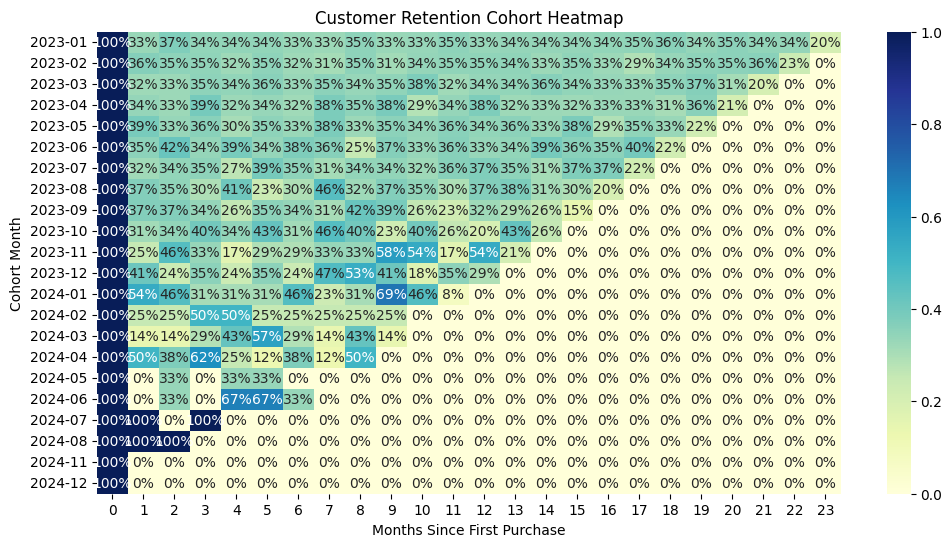

<Figure size 640x480 with 0 Axes>

In [ ]:
from pyspark.sql.functions import min, date_format, col, months_between, floor, countDistinct, sum
import matplotlib.pyplot as plt
import seaborn as sns

# Load transactions
transactions_df = spark.table("workspace.default.transactions")

# Cohort creation
cohort_df = transactions_df.groupBy("customer_id") \
    .agg(min("transaction_date").alias("cohort_date"))

cohort_data = transactions_df.join(cohort_df, "customer_id")

cohort_data = cohort_data \
    .withColumn("cohort_month", date_format("cohort_date", "yyyy-MM")) \
    .withColumn("activity_month", date_format("transaction_date", "yyyy-MM")) \
    .withColumn("cohort_index",
        floor(months_between(col("transaction_date"), col("cohort_date")))
    )

# Retention table
cohort_retention = cohort_data.groupBy("cohort_month", "cohort_index") \
    .agg(countDistinct("customer_id").alias("customers"))

# Convert to pandas
retention_pd = cohort_retention.toPandas()
retention_pivot = retention_pd.pivot(index="cohort_month", columns="cohort_index", values="customers")

# Normalize %
retention_pct = retention_pivot.divide(retention_pivot.iloc[:,0], axis=0).fillna(0)

#  Plot retention heatmap
plt.figure(figsize=(12,6))
sns.heatmap(retention_pct, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title("Customer Retention Cohort Heatmap")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")
plt.show()

#  Clear matplotlib buffer (prevents blank graph)
plt.clf()